<a href="https://colab.research.google.com/github/Auta01/Hugging-face/blob/main/Image_Gen_Diffuser_lib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Generating face using Diffusion models
from diffusers import DDPMPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
ddpm = DDPMPipeline.from_pretrained('google/ddpm-celebahq-256').to('cuda')

In [ ]:
image = ddpm(num_inference_steps=30).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

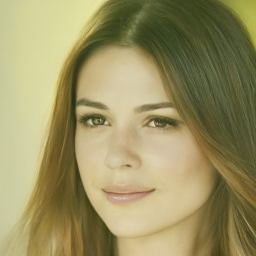

In [ ]:
image

In [ ]:
from diffusers import DDPMScheduler, UNet2DModel

In [ ]:
scheduler = DDPMScheduler.from_pretrained('google/ddpm-celebahq-256')

In [ ]:
scheduler

In [ ]:
model = UNet2DModel.from_pretrained('google/ddpm-celebahq-256').to('cuda')

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [ ]:
model

In [ ]:
scheduler.set_timesteps(50)

In [ ]:
scheduler.timesteps

tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800, 780, 760, 740, 720,
        700, 680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440,
        420, 400, 380, 360, 340, 320, 300, 280, 260, 240, 220, 200, 180, 160,
        140, 120, 100,  80,  60,  40,  20,   0])

In [ ]:
import torch

In [ ]:
sample_size = model.config.sample_size

In [ ]:
sample_size

256

In [ ]:

noise =torch.randn(1,3,sample_size, device=('cuda'))

In [ ]:
noise

tensor([[[[ 0.6869, -0.4397, -1.0536,  ..., -1.5569, -0.5515, -0.4635],
          [-0.1416, -1.0951,  0.2516,  ...,  0.3388, -0.2102,  0.3785],
          [ 0.4462,  2.8347,  0.1080,  ...,  0.1796,  0.1730,  0.4254],
          ...,
          [-0.0301, -0.3735,  0.3299,  ...,  1.7145, -0.2210, -0.3942],
          [-0.0135, -0.1926, -0.4915,  ..., -0.4257,  0.7515,  1.1199],
          [-1.2727,  0.9948, -0.0368,  ..., -0.3239, -0.4258, -0.8267]],

         [[ 0.4400, -0.1970, -0.2800,  ...,  1.5740,  0.9773, -1.3292],
          [ 0.3553,  0.1026,  1.8135,  ...,  0.9022,  1.3264,  0.3071],
          [-1.1588, -0.4958, -1.5420,  ...,  0.5147, -0.0733, -0.8760],
          ...,
          [-0.3768, -0.8274,  0.5347,  ...,  0.3523, -0.0429, -1.0793],
          [ 0.2597,  0.8994, -0.0878,  ...,  0.2738,  1.1517,  0.7206],
          [-0.2511,  0.7449,  0.4646,  ..., -0.4374,  0.6229,  1.0474]],

         [[ 1.8647, -0.4708, -0.5230,  ..., -0.3243,  0.8493,  0.2860],
          [ 0.0037,  0.7341,  

In [ ]:
import matplotlib.pyplot as plt

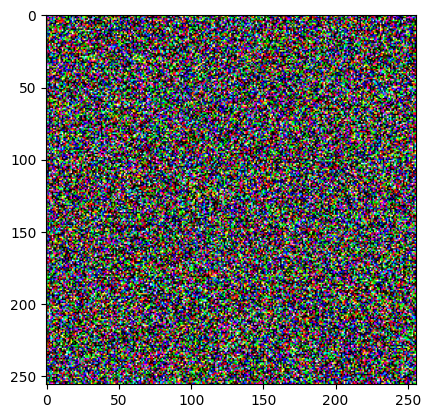

In [ ]:
input = noise
plt.imshow(input.squeeze().permute(1,2,0).detach().to('cpu').numpy());

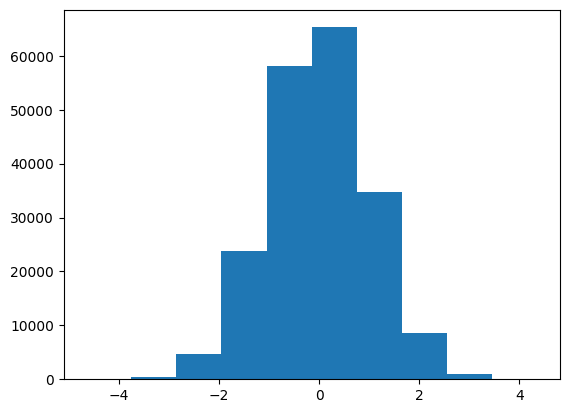

In [ ]:
plt.hist(input.squeeze().permute(1,2,0).detach().to('cpu').numpy().flatten());

In [ ]:


for t in scheduler.timesteps:
   with torch.inference_mode():
     noisy_residual =model(input,t).sample
     previous_noisy_sample =scheduler.step(noisy_residual,t,input).prev_sample
     input = previous_noisy_sample

In [ ]:
from PIL import Image
import numpy as np


In [ ]:
image = (input/2+0.5).clamp(0,1).squeeze()

In [ ]:
image = (image.permute(1,2,0)*255).round().to(torch.uint8).cpu().numpy()

In [ ]:
image = Image.fromarray(image)

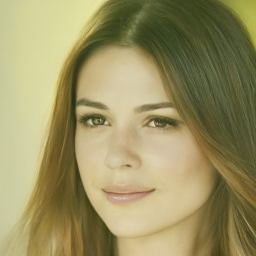

In [ ]:
image

In [ ]:
##Generating image using a prompt with Diffusion models


In [ ]:
import torch
from diffusers import DiffusionPipeline

# Load the pipeline using float16 for reduced memory usage and balanced device mapping.
# device_map="balanced" intelligently places model parts on available devices (GPU/CPU) to manage memory.
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    device_map="balanced"
)

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

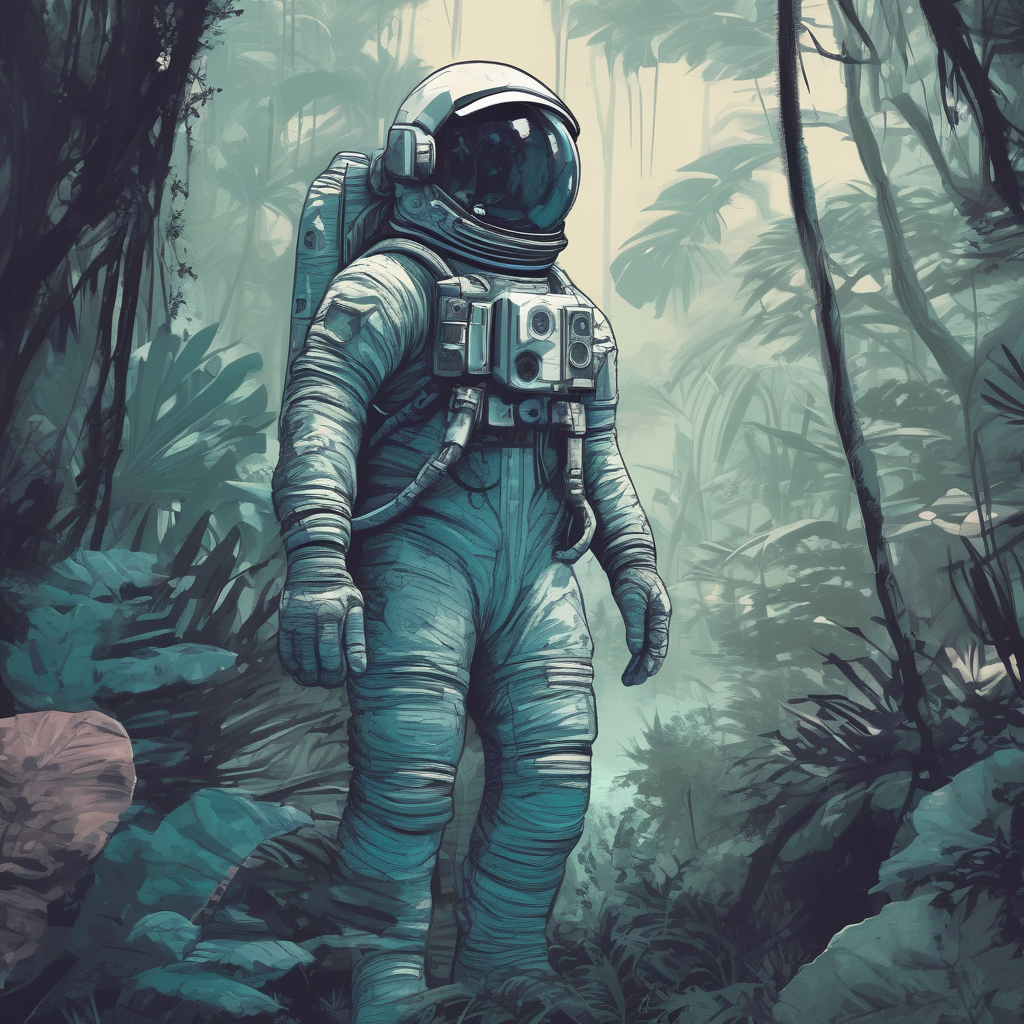